# Clustering: Gaussian Mixture Model (GMM)

K-Means makes two rigid assumptions: every cluster is roughly **spherical**, and every point gets a **hard** either/or cluster label. A **Gaussian Mixture Model** relaxes both:
- Each cluster is modeled as its own **Gaussian distribution** with its own mean *and* covariance -- so clusters can be **elliptical**, tilted, and different sizes/shapes from one another, not forced into circles.
- Instead of a hard label, GMM gives every point a **probability of belonging to each cluster** (`predict_proba`) -- "soft" clustering. A point near the boundary between two segments can honestly be reported as, say, 55% cluster A / 45% cluster B, rather than being arbitrarily forced into one or the other.

Part A demonstrates GMM's advantage on synthetic elliptical clusters, where K-Means visibly distorts the true groups. Part B applies it to the Mall Customers dataset and compares against K-Means.

## 0. Install & Import Libraries

In [1]:
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries loaded.")


Libraries loaded.


## Part A: Why Gaussian Mixtures? A Synthetic Demo

Generate 3 blobs, then deliberately stretch/tilt them into ellipses using a linear transform -- something real data (e.g. correlated features) does naturally, and something K-Means' circular-cluster assumption handles poorly.

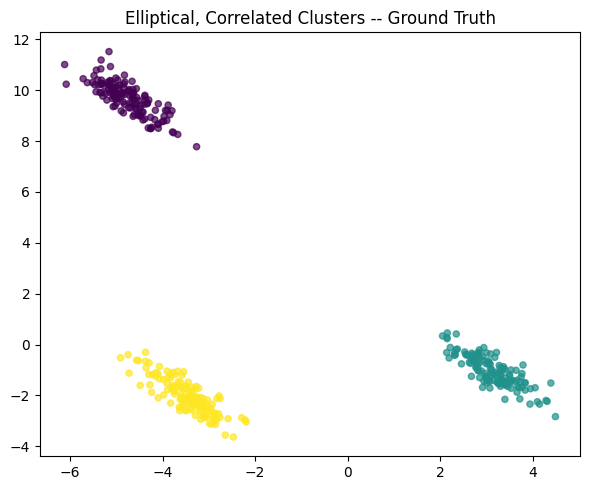

In [2]:
X_blobs, y_blobs_true = make_blobs(n_samples=400, centers=3, cluster_std=0.6, random_state=SEED)

# Stretch/rotate to create elliptical, correlated clusters
transformation = np.array([[0.8, -0.6], [-0.3, 0.9]])
X_elliptical = X_blobs @ transformation

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_elliptical[:, 0], X_elliptical[:, 1], c=y_blobs_true, cmap="viridis", s=20, alpha=0.7)
ax.set_title("Elliptical, Correlated Clusters -- Ground Truth")
plt.tight_layout()
plt.show()


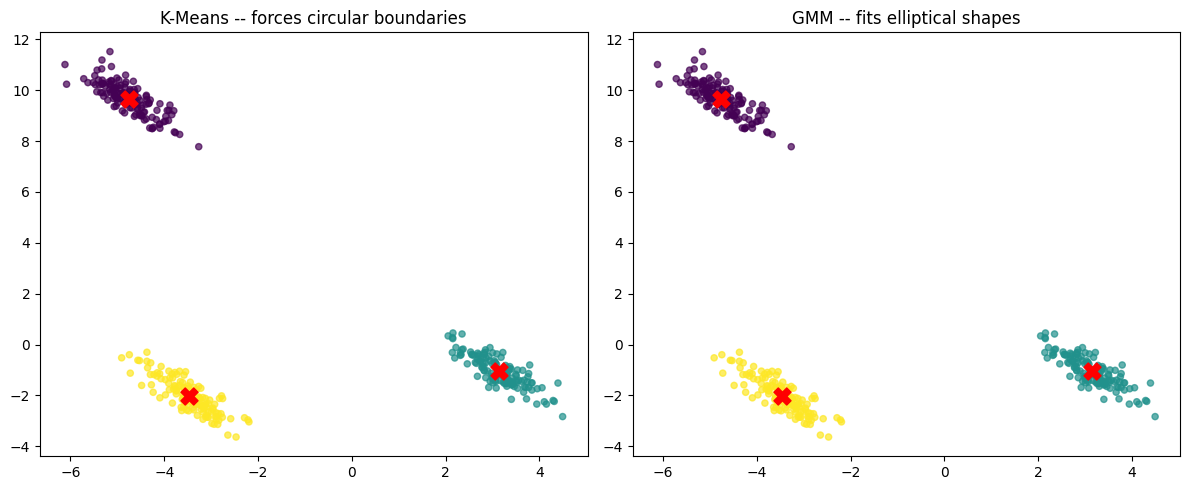

In [3]:
kmeans_e = KMeans(n_clusters=3, random_state=SEED, n_init=10)
kmeans_e_labels = kmeans_e.fit_predict(X_elliptical)

gmm_e = GaussianMixture(n_components=3, random_state=SEED)
gmm_e_labels = gmm_e.fit_predict(X_elliptical)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_elliptical[:, 0], X_elliptical[:, 1], c=kmeans_e_labels, cmap="viridis", s=20, alpha=0.7)
axes[0].scatter(kmeans_e.cluster_centers_[:, 0], kmeans_e.cluster_centers_[:, 1], c="red", marker="X", s=150)
axes[0].set_title("K-Means -- forces circular boundaries")

axes[1].scatter(X_elliptical[:, 0], X_elliptical[:, 1], c=gmm_e_labels, cmap="viridis", s=20, alpha=0.7)
axes[1].scatter(gmm_e.means_[:, 0], gmm_e.means_[:, 1], c="red", marker="X", s=150)
axes[1].set_title("GMM -- fits elliptical shapes")

plt.tight_layout()
plt.show()


K-Means partitions space using perpendicular-bisector (Voronoi) boundaries between centroids -- which are only correct if clusters are circular and equally sized. Where the true clusters overlap or stretch diagonally, K-Means visibly misassigns points along the boundary. GMM instead fits each cluster's own covariance (spread and orientation), so its decision boundary bends to match each cluster's actual elliptical shape.

## Part B: Mall Customer Segmentation with GMM

In [4]:
DATA_URL = "https://raw.githubusercontent.com/lucko515/clustering-python/master/Customer%20in%20Mall%20clusterng/Mall_Customers.csv"
DATA_DIR = "data"
LOCAL_PATH = os.path.join(DATA_DIR, "Mall_Customers.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(LOCAL_PATH):
    print(f"Loading data from local cache: {LOCAL_PATH}")
    df_raw = pd.read_csv(LOCAL_PATH)
else:
    print(f"Local file not found. Downloading from {DATA_URL} ...")
    df_raw = pd.read_csv(DATA_URL)
    df_raw.to_csv(LOCAL_PATH, index=False)
    print(f"Saved local copy to: {LOCAL_PATH}")

df = df_raw.drop_duplicates().reset_index(drop=True).drop(columns=["CustomerID"])
print("Shape:", df.shape)
df.head()


Local file not found. Downloading from https://raw.githubusercontent.com/lucko515/clustering-python/master/Customer%20in%20Mall%20clusterng/Mall_Customers.csv ...
Saved local copy to: data/Mall_Customers.csv
Shape: (200, 4)


,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [5]:
cluster_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

scaler = StandardScaler()
X_proc = scaler.fit_transform(df[cluster_features])
print("Scaled. Shape:", X_proc.shape)


Scaled. Shape: (200, 3)


### Choosing `n_components` with BIC / AIC

GMM is fit by maximizing likelihood, so unlike K-Means we can use proper **information criteria** to pick the number of components -- **BIC** (Bayesian Information Criterion) and **AIC** (Akaike Information Criterion) both balance model fit against model complexity (more components = more parameters = risk of overfitting), penalizing over-complex models. **Lower is better** for both. BIC penalizes complexity more heavily than AIC, so it tends to prefer simpler (smaller `n_components`) models.

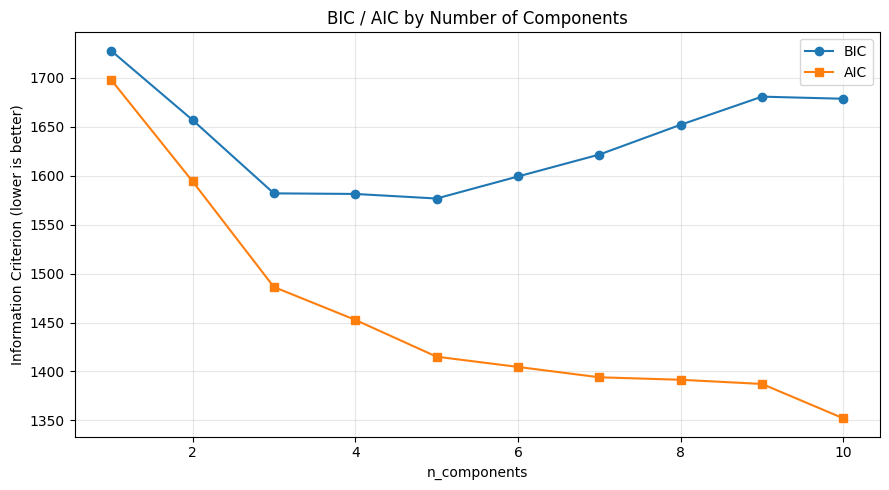

In [6]:
n_components_range = range(1, 11)
bic_scores, aic_scores = [], []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=SEED, n_init=5)
    gmm.fit(X_proc)
    bic_scores.append(gmm.bic(X_proc))
    aic_scores.append(gmm.aic(X_proc))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(n_components_range), bic_scores, "-o", label="BIC")
ax.plot(list(n_components_range), aic_scores, "-s", label="AIC")
ax.set_xlabel("n_components")
ax.set_ylabel("Information Criterion (lower is better)")
ax.set_title("BIC / AIC by Number of Components")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
BEST_N_BIC = list(n_components_range)[int(np.argmin(bic_scores))]
BEST_N_AIC = list(n_components_range)[int(np.argmin(aic_scores))]
print(f"BIC-optimal n_components: {BEST_N_BIC}")
print(f"AIC-optimal n_components: {BEST_N_AIC}")

# BIC's stronger complexity penalty is generally the more trustworthy pick for choosing
# a clustering that will generalize, rather than just fitting this exact sample as tightly as possible.
BEST_N = BEST_N_BIC
print(f"\nUsing n_components = {BEST_N} (BIC)")


BIC-optimal n_components: 5
AIC-optimal n_components: 10

Using n_components = 5 (BIC)


### Fit the Final GMM

In [8]:
final_gmm = GaussianMixture(n_components=BEST_N, random_state=SEED, n_init=10)
final_gmm.fit(X_proc)

hard_labels = final_gmm.predict(X_proc)        # hard cluster assignment
soft_probs = final_gmm.predict_proba(X_proc)   # probability of belonging to each cluster

df["gmm_cluster"] = hard_labels
print(pd.Series(hard_labels).value_counts().sort_index().rename("customer_count"))


0    23
1    53
2    39
3    34
4    51
Name: customer_count, dtype: int64


### Soft Clustering in Action: Points Near a Boundary

The real payoff of GMM over K-Means: pull out the customers whose top-2 cluster probabilities are closest together -- these are genuinely ambiguous cases sitting between two segments, something K-Means' hard labels would hide entirely.

In [9]:
sorted_probs = np.sort(soft_probs, axis=1)
top1 = sorted_probs[:, -1]
top2 = sorted_probs[:, -2]
ambiguity = top1 - top2  # small gap = genuinely ambiguous point

df["top_cluster_prob"] = top1.round(3)
df["prob_margin"] = ambiguity.round(3)

print("5 most ambiguous customers (smallest probability margin between top 2 clusters):")
df.sort_values("prob_margin").head(5)[cluster_features + ["gmm_cluster", "top_cluster_prob", "prob_margin"]]


5 most ambiguous customers (smallest probability margin between top 2 clusters):


,Age,Annual Income (k$),Spending Score (1-100),gmm_cluster,top_cluster_prob,prob_margin
146,48,77,36,3,0.510,0.019
88,34,58,60,1,0.449,0.096
94,32,60,42,4,0.603,0.207
69,32,48,47,1,0.605,0.215
49,31,40,42,1,0.611,0.360


### Visualize the Clusters with Their Covariance Ellipses

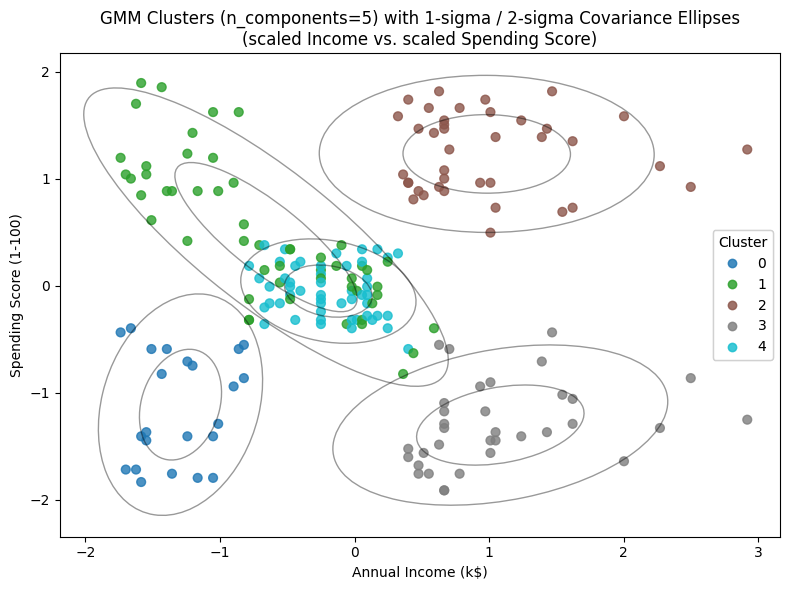

In [10]:
def plot_gmm_ellipses(ax, gmm, feature_idx_x, feature_idx_y, feature_names):
    for i in range(gmm.n_components):
        mean = gmm.means_[i][[feature_idx_x, feature_idx_y]]
        cov_full = gmm.covariances_[i]
        cov = cov_full[np.ix_([feature_idx_x, feature_idx_y], [feature_idx_x, feature_idx_y])]

        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        order = eigenvalues.argsort()[::-1]
        eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

        for n_std in [1, 2]:
            width, height = 2 * n_std * np.sqrt(eigenvalues)
            ellipse = mpl.patches.Ellipse(mean, width, height, angle=angle, edgecolor="black", facecolor="none", alpha=0.4, linewidth=1)
            ax.add_patch(ellipse)

    ax.set_xlabel(feature_names[feature_idx_x])
    ax.set_ylabel(feature_names[feature_idx_y])


fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_proc[:, 1], X_proc[:, 2], c=hard_labels, cmap="tab10", s=40, alpha=0.8)
plot_gmm_ellipses(ax, final_gmm, 1, 2, cluster_features)
ax.set_title(f"GMM Clusters (n_components={BEST_N}) with 1-sigma / 2-sigma Covariance Ellipses\n(scaled Income vs. scaled Spending Score)")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.show()


The ellipses show each cluster's actual learned shape and orientation -- notice they aren't uniform circles the way K-Means would implicitly assume. Some segments are more elongated or tilted than others, reflecting real correlation between income and spending within that group.

### Interpret the Clusters

In [11]:
cluster_profile = df.groupby("gmm_cluster")[cluster_features].mean().round(1)
cluster_profile["customer_count"] = df["gmm_cluster"].value_counts().sort_index()
cluster_profile["avg_confidence"] = df.groupby("gmm_cluster")["top_cluster_prob"].mean().round(3)

cluster_profile


,Age,Annual Income (k$),Spending Score (1-100),customer_count,avg_confidence
gmm_cluster,,,,,
0,45.2,26.3,20.9,23,0.990
1,24.8,43.2,62.0,53,0.948
2,32.7,86.5,82.1,39,1.000
3,41.6,88.7,16.8,34,0.965
4,53.4,55.4,49.0,51,0.980


### Compare GMM vs. K-Means

In [12]:
kmeans_ref = KMeans(n_clusters=BEST_N, random_state=SEED, n_init=10)
kmeans_ref_labels = kmeans_ref.fit_predict(X_proc)

comparison = pd.DataFrame({
    "GMM": [
        silhouette_score(X_proc, hard_labels),
        davies_bouldin_score(X_proc, hard_labels),
        calinski_harabasz_score(X_proc, hard_labels),
    ],
    "K-Means": [
        silhouette_score(X_proc, kmeans_ref_labels),
        davies_bouldin_score(X_proc, kmeans_ref_labels),
        calinski_harabasz_score(X_proc, kmeans_ref_labels),
    ],
}, index=["Silhouette (higher better)", "Davies-Bouldin (lower better)", "Calinski-Harabasz (higher better)"])

comparison.round(3)


,GMM,K-Means
Silhouette (higher better),0.406,0.417
Davies-Bouldin (lower better),0.936,0.875
Calinski-Harabasz (higher better),116.901,125.101


These clustering-quality metrics tend to structurally favor K-Means, since silhouette/Davies-Bouldin/Calinski-Harabasz are themselves built around Euclidean distance to a single center -- exactly the geometry K-Means was optimized for. GMM's real advantage isn't a better score on these particular metrics; it's the elliptical cluster shapes and the calibrated, honest uncertainty (`predict_proba`) for points near a boundary, which none of these hard-label metrics can capture at all.

## Inference on a New Customer

In [13]:
def predict_gmm_membership(age, annual_income_k, spending_score, model, scaler):
    input_df = pd.DataFrame([{
        "Age": age,
        "Annual Income (k$)": annual_income_k,
        "Spending Score (1-100)": spending_score,
    }])
    input_scaled = scaler.transform(input_df)
    hard_pred = model.predict(input_scaled)[0]
    probs = model.predict_proba(input_scaled)[0]
    return hard_pred, probs


hard_pred, probs = predict_gmm_membership(27, 85, 90, final_gmm, scaler)
print(f"Most likely cluster: {hard_pred}")
print("Probability of belonging to each cluster:")
for i, p in enumerate(probs):
    print(f"  Cluster {i}: {p:.3f}")


Most likely cluster: 2
Probability of belonging to each cluster:
  Cluster 0: 0.000
  Cluster 1: 0.000
  Cluster 2: 1.000
  Cluster 3: 0.000
  Cluster 4: 0.000


## Save the Model (optional)

In [14]:
joblib.dump({"model": final_gmm, "scaler": scaler, "features": cluster_features}, "mall_gmm.joblib")
print("Model + scaler saved to mall_gmm.joblib")


Model + scaler saved to mall_gmm.joblib
